## Intruções sobre o Teste

Este Jupyter Notebook apresenta-se como **um roteiro que auxilia a reponder perguntas** disponibilizadas na Plataforma Moodle da Universidade Lusófona.

Submeta este ficheiro na plataforma em campo indicado quando finalizar o teste.

### Regras do Teste:

- A questões a serem avaliadas no Moodle possuem valores de 0 a 1.
- Uma ou mais alternativas podem estar corretas.
- Escolher uma alternativa errada, anula uma correta.
- Mesmo marcando apenas alternativas erradas a maior penalização é 0 valor naquela questão.
- Não esqueça de submeter o ficheiro Jupyter Notebook respondido.

### Regras de conduta:

- **Não é permitido(a):**
    - a consulta a materiais das aulas.
    - a consulta a demais colegas de classe.
    - uso de aparelhos eletrônicos tais como smartphones, smartwatches, etc.
    - uso de aplicativos de mensagem instantânea durante o teste.

- **É permitido(a):**
    - uso de IA generativa

---

### `Nome`: Fábio Jorge
### `Aluno ID`: a22303085
---

### Bom Teste!!!

**Importe as bibliotecas**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import spearmanr, pearsonr, chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

pd.set_option('display.max_columns', None)

Considerando o dataset fornecido, siga os passos abaixo para responder às perguntas disponibilizadas no Moodle:

### Dicionário de Dados:

| **Variable**                        | **Description**                                            | **Units**                  |
| ----------------------------------- | ---------------------------------------------------------- | -------------------------- |
| **Country**                         | Nome do país                                               | —                          |
| **Year**                            | Ano da observação                                          | Ano                        |
| **Status**                          | Classificação socioeconômica                               | —                          |
| **Life expectancy**                 | Expectativa de vida ao nascer                              | Anos                       |
| **Adult Mortality**                 | Probabilidade de morte entre 15–60 anos                    | Mortes por 1000 adultos    |
| **infant deaths**                   | Número de mortes de bebês menores de 1 ano                 | Contagem                   |
| **Alcohol**                         | Consumo de álcool per capita                               | Litros por pessoa          |
| **percentage expenditure**          | Despesa per capita com saúde em relação ao PIB             | Percentual                 |
| **Hepatitis B**                     | Cobertura vacinal contra Hepatite B em crianças de 1 ano   | Percentual                 |
| **Measles**                         | Número de casos reportados de sarampo                      | Contagem                   |
| **BMI**                             | Índice de Massa Corporal médio da população                | kg/m²                      |
| **under-five deaths**               | Mortes de crianças menores de 5 anos                       | Contagem                   |
| **Polio**                           | Cobertura vacinal contra poliomielite em crianças de 1 ano | Percentual                 |
| **Total expenditure**               | Despesa governamental total com saúde                      | Percentual do orçamento    |
| **Diphtheria**                      | Cobertura vacinal contra difteria em crianças de 1 ano     | Percentual                 |
| **HIV/AIDS**                        | Taxa de mortalidade por HIV/AIDS                           | Mortes por 1000 habitantes |
| **GDP**                             | Produto Interno Bruto per capita                           | USD                        |
| **Population**                      | População total do país                                    | Habitantes                 |
| **thinness 1-19 years**             | Prevalência de magreza entre 1–19 anos                     | Percentual                 |
| **thinness 5-9 years**              | Prevalência de magreza entre 5–9 anos                      | Percentual                 |
| **Income composition of resources** | Índice de desenvolvimento humano (componente renda)        | Escala 0–1                 |
| **Schooling**                       | Média de anos de escolaridade                              | Anos                       |


### Q1. Carregue o dataset em um DataFrame.

In [2]:
# your code here
df = pd.read_csv('test_dataset.csv')

### Q2. Identifique as variáveis numéricas e categóricas presentes no dataset.

In [3]:
# your code here
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       2938 non-null   int64  
 1   Country                          2938 non-null   object 
 2   Year                             2938 non-null   int64  
 3   Status                           2938 non-null   object 
 4   Life_expectancy                  2928 non-null   float64
 5   Adult_Mortality                  2928 non-null   float64
 6   infant_deaths                    2938 non-null   int64  
 7   Alcohol                          2744 non-null   float64
 8   percentage_expenditure           2938 non-null   float64
 9   Hepatitis_B                      2385 non-null   float64
 10  Measles                          2938 non-null   int64  
 11  BMI                              2904 non-null   float64
 12  under-five_deaths   

In [7]:
df.describe()

,Unnamed: 0,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,percentage_expenditure,Hepatitis_B,Measles,BMI,under-five_deaths,Polio,Total_expenditure,Diphtheria,HIV_AIDS,GDP,Population,thinness_1-19_years,thinness_5-9_years,Income_composition_of_resources,Schooling
count,2938.000000,2938.000000,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,1468.500000,2007.518720,0.174268,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,848.271871,4.613841,0.379405,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,0.000000,2000.000000,0.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,734.250000,2004.000000,0.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,1468.500000,2008.000000,0.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2202.750000,2012.000000,0.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2937.000000,2015.000000,1.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


Resposta: Todas são variáveis numéricas, exceto Country e Status que são categóricas.

### Q3. Crie um boxplot e compare a expectativa de vida entre países desenvolvidos e em desenvolvimento.

In [5]:
df['Status'] = df['Status'].map({'Developed': 1,'Developing': 0})

In [6]:
print("Depois:", df['Status'].value_counts())

Depois: Status
0    2426
1     512
Name: count, dtype: int64


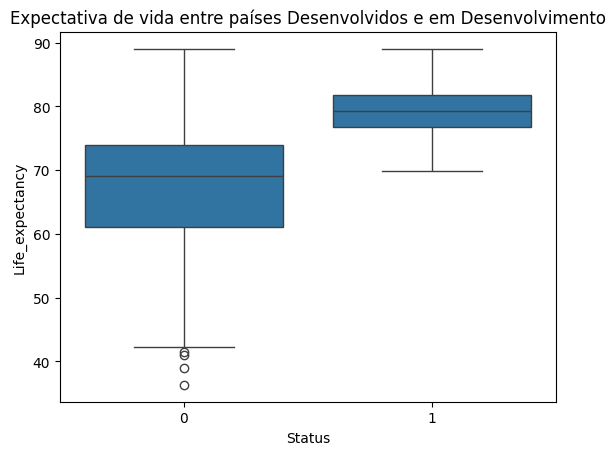

In [10]:
# your code here
sns.boxplot(data=df, x='Status', y='Life_expectancy')
plt.title('Expectativa de vida entre países Desenvolvidos e em Desenvolvimento')
plt.show()

### Q4. Considerando os paises **Desenvolvidos** e **Em Desenvolvimento**:

### Q4.1. Para os paises desenvolvidos:

- a) Identifique o país com maior PIB médio e o com menor PIB médio considerando todos os anos disponíveis.
- b) Qual deles tem maior expectativa de vida média?
- c) Qual apresenta maior mortalidade adulta?
- d) Qual possui maior consumo médio de álcool?
- e) Qual apresenta maior valor médio de escolaridade?

In [15]:
paises_desenvolvidos = df[df['Status'] == 1].copy()
media_pais = paises_desenvolvidos.groupby('Country').mean(numeric_only=True)

In [20]:
print(df.columns.tolist())

['Unnamed: 0', 'Country', 'Year', 'Status', 'Life_expectancy', 'Adult_Mortality', 'infant_deaths', 'Alcohol', 'percentage_expenditure', 'Hepatitis_B', 'Measles', 'BMI', 'under-five_deaths', 'Polio', 'Total_expenditure', 'Diphtheria', 'HIV_AIDS', 'GDP', 'Population', 'thinness_1-19_years', 'thinness_5-9_years', 'Income_composition_of_resources', 'Schooling']


In [16]:
# a)

pais_pib_maior = media_pais['GDP'].idxmax()
pais_pib_menor = media_pais['GDP'].idxmin()

print(f"a) País com maior PIB: {pais_pib_maior}")
print(f"a) País com menor PIB: {pais_pib_menor}")

a) País com maior PIB: Switzerland
a) País com menor PIB: Romania


In [19]:
# b)
comparacao = media_pais.loc[[pais_pib_maior, pais_pib_menor]]

colunas_interesse = ['Life_expectancy', 'Adult_Mortality', 'Alcohol', 'Schooling', 'GDP']
tabela_final = comparacao[colunas_interesse]

print(tabela_final)


             Life_expectancy  Adult_Mortality    Alcohol  Schooling  \
Country                                                               
Switzerland         82.33125          55.7500  10.338000   15.39375   
Romania             74.05000         156.0625   8.968667   13.92500   

                      GDP  
Country                    
Switzerland  57362.874601  
Romania       4258.940054  


Resposta: O país que apresenta maior esperança de vida média é a Suiça,

In [ ]:
# c)

Resposta: O país que apresenta uma maior mortalidade na vida adulta é a Roménia.

In [ ]:
# d)

Resposta: O país que tem o maior consumo médio de álcool é a Suiça.

In [ ]:
# e)

Resposta: Suiça apresenta o maior valor médio de escolaridade

### Q4.2. Para os paises em desenvolvimento:

- a) Identifique o país com maior PIB médio e o com menor PIB médio considerando todos os anos disponíveis.
- b) Qual deles tem maior expectativa de vida média?
- c) Qual apresenta maior mortalidade adulta?
- d) Qual possui maior consumo médio de álcool?
- e) Qual apresenta maior valor médio de escolaridade?

In [21]:
paises_em_desenvolvimento = df[df['Status'] == 0].copy()
media_pais = paises_em_desenvolvimento.groupby('Country').mean(numeric_only=True)


In [23]:
# a)
pais_pib_maior = media_pais['GDP'].idxmax()
pais_pib_menor = media_pais['GDP'].idxmin()

print(f"a) País em desenvolvimento com maior PIB: {pais_pib_maior}")
print(f"a) País em desenvolvimento com menor PIB: {pais_pib_menor}")

a) País em desenvolvimento com maior PIB: Qatar
a) País em desenvolvimento com menor PIB: Nauru


In [24]:
# b)
comparacao = media_pais.loc[[pais_pib_maior, pais_pib_menor]]

colunas_interesse = ['Life_expectancy', 'Adult_Mortality', 'Alcohol', 'Schooling', 'GDP']
tabela_final = comparacao[colunas_interesse]

print(tabela_final)

         Life_expectancy  Adult_Mortality   Alcohol  Schooling           GDP
Country                                                                     
Qatar           77.03125           75.375  1.081333      12.85  40748.444104
Nauru                NaN              NaN  0.010000       9.60    136.183210


Resposta: Qatar tem maior esperança média de vida.

In [ ]:
# c)

Resposta: Nauru nem apresenta dados

In [ ]:
# d)

Resposta: Qatar consome mais álcool.

In [ ]:
# e)

Resposta: Qatar tem maior valor médio de escolaridade

### Q4.3. Considerando o País Desenvolvido com Maior PIB Médio identificado em 4.1:

- Gere um histograma da variável Life_expectancy desse país ao longo dos anos disponíveis

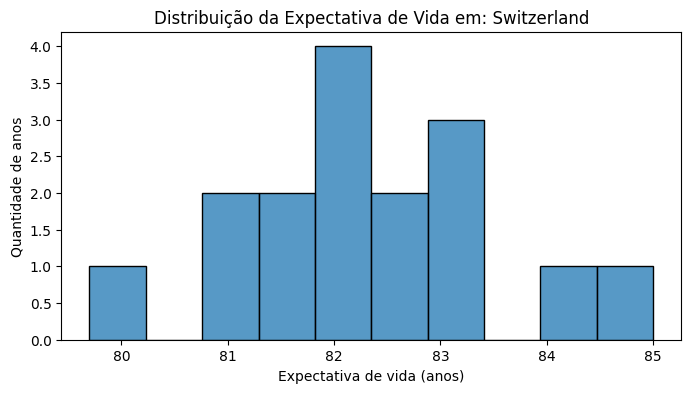

In [31]:
paises_desenvolvidos = df[df['Status'] == 1]
medias_gdp = paises_desenvolvidos.groupby('Country')['GDP'].mean()

pais_pretendido = medias_gdp.idxmax()

dados_pais = df[df['Country'] == pais_pretendido]

plt.figure(figsize=(8, 4))

# kde=True adiciona a linha suave da curva de densidade
sns.histplot(data=dados_pais, x='Life_expectancy', bins=10)

plt.title(f'Distribuição da Expectativa de Vida em: {pais_pretendido}')
plt.xlabel('Expectativa de vida (anos)')
plt.ylabel('Quantidade de anos')
plt.show()


### Q5. Considerando a expectativa de vida como variável independente, construa modelo de Regressão Linear Simples com a variável dependente que apresenta maior correlação.
- Guarde este modelo numa variável `model_q5` para referência futura.

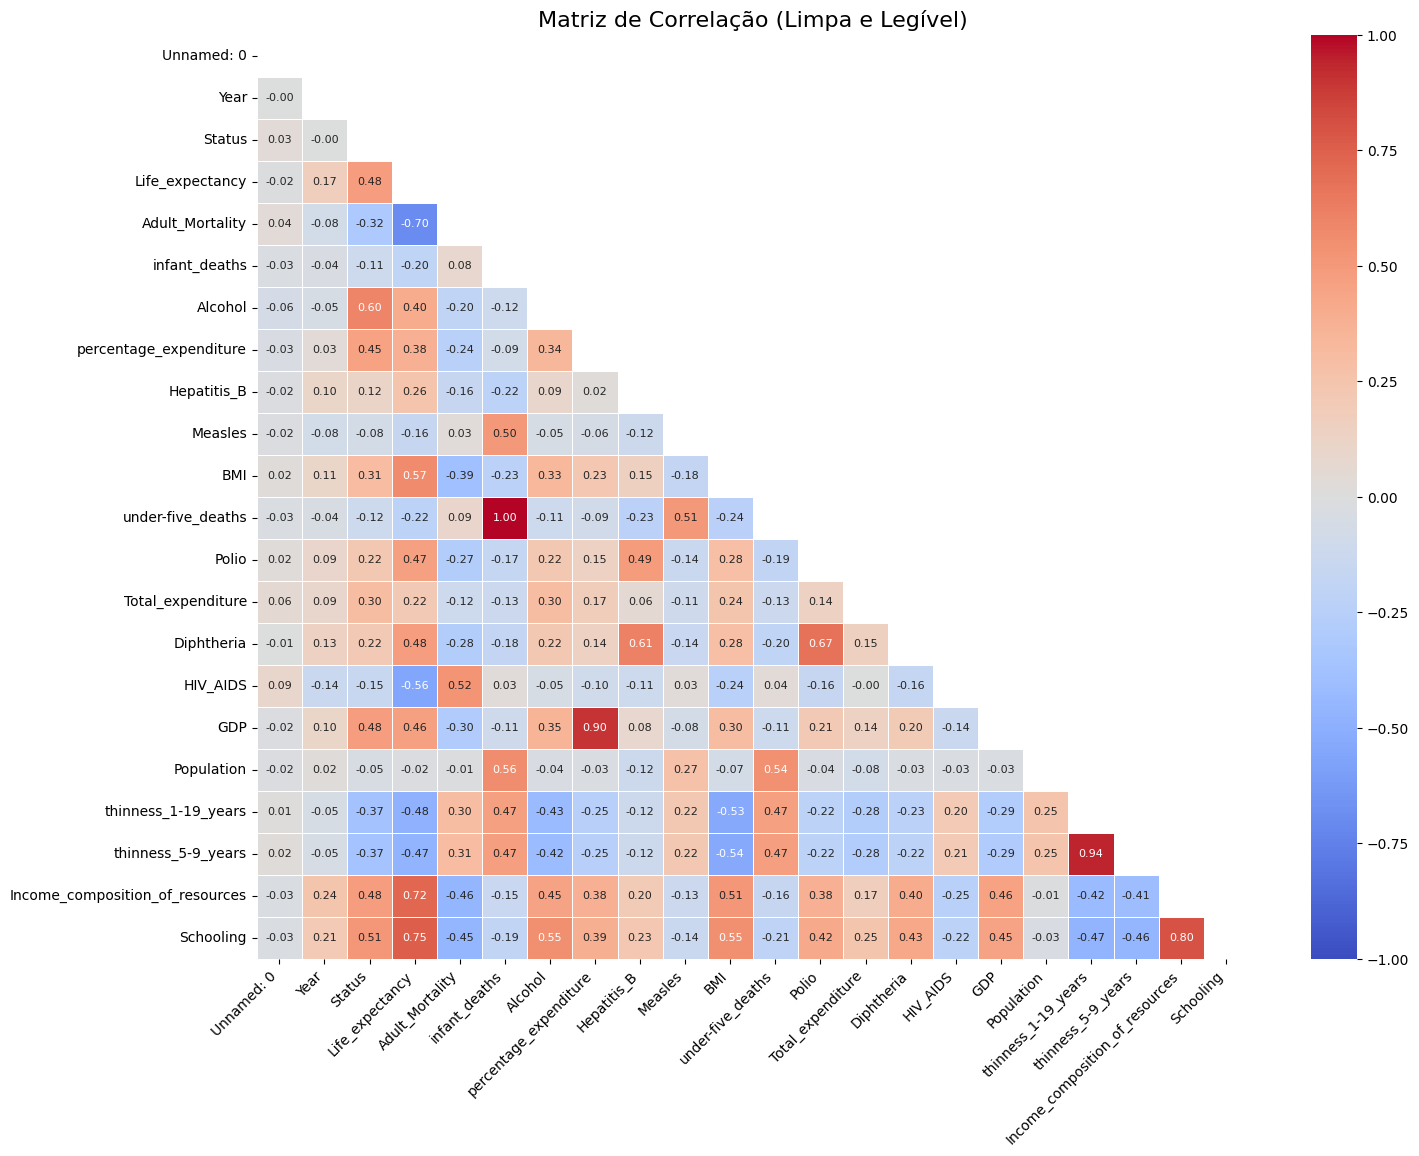

In [39]:
#sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

# 1. Calcular a correlação
corr = df.corr(numeric_only=True)

# 2. Criar uma MÁSCARA para esconder o triângulo superior
# (Como a matriz é espelhada, a parte de cima é repetida e só cria ruído visual)
mask = np.triu(np.ones_like(corr, dtype=bool))

# 3. Aumentar o tamanho da figura (O passo mais importante para evitar sobreposição)
plt.figure(figsize=(16, 12))

# 4. Gerar o Heatmap Otimizado
sns.heatmap(corr,
            mask=mask,           # Aplica a máscara
            annot=True,          # Mostra os números
            fmt=".2f",           # Arredonda para 2 casas decimais (poupa espaço!)
            cmap='coolwarm',     # Cores (Azul-Vermelho)
            vmin=-1, vmax=1,     # Garante escala real de -1 a 1
            center=0,            # Garante que o branco é o zero
            linewidths=0.5,      # Linhas brancas para separar os quadrados
            annot_kws={"size": 8}) # Reduz o tamanho da fonte dos números

plt.xticks(rotation=45, ha='right') # Roda os nomes em baixo para ler melhor
plt.title('Matriz de Correlação (Limpa e Legível)', fontsize=16)
plt.show()

In [36]:
# your code here
correlacoes = df.corr(numeric_only=True)['Life_expectancy']

correlacoes = correlacoes.drop('Life_expectancy')

melhor_dependente = correlacoes.abs().idxmax()
valor_corr = correlacoes[melhor_dependente]

print(f"A variável selecionada como Dependente (y) é: '{melhor_dependente}'")
print(f"Correlação encontrada: {valor_corr:.4f}")


A variável selecionada como Dependente (y) é: 'Schooling'
Correlação encontrada: 0.7520


In [37]:

coluna_x = 'Life_expectancy'
coluna_y = 'Schooling'

dados_limpos = df[[coluna_x, coluna_y]].dropna()
X = dados_limpos[coluna_x]
y = dados_limpos[coluna_y]

X_sm = sm.add_constant(X)

model_q5 = sm.OLS(y, X_sm).fit()

print(model_q5.summary())

                            OLS Regression Results                            
Dep. Variable:              Schooling   R-squared:                       0.565
Model:                            OLS   Adj. R-squared:                  0.565
Method:                 Least Squares   F-statistic:                     3599.
Date:                Tue, 09 Dec 2025   Prob (F-statistic):               0.00
Time:                        09:12:30   Log-Likelihood:                -6117.0
No. Observations:                2768   AIC:                         1.224e+04
Df Residuals:                    2766   BIC:                         1.225e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -6.6435      0.314    -

In [ ]:
# your code here


### Q6. Faça plots de diagnóstico

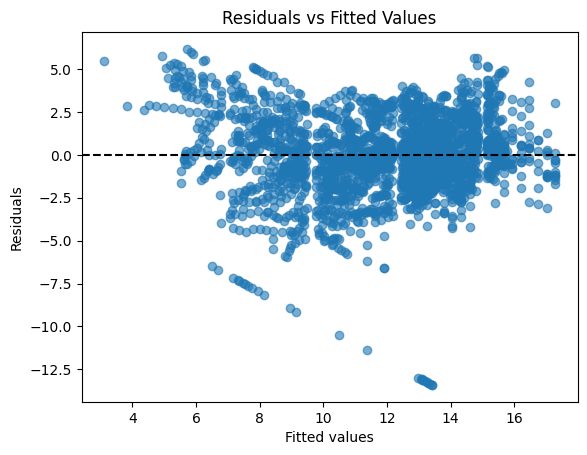

In [38]:
# your code here
# Definir os dados vindos do modelo q5
fitted = model_q5.fittedvalues
residuals = model_q5.resid

plt.figure(figsize=(10, 6))
plt.scatter(fitted, residuals, alpha=0.6, color='blue')
plt.axhline(0, color='', linestyle='--')

plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

### Q7. Verifique a mediana da variável independente e faça predições do modelo para a mediana e mais 2 valores acrescidos em 5 unidades.

**Exemplo**:
>
>Se **mediana == 5.21**
>
>Fazer predições do modelo para **5.21, 10.21, 15.21**

In [40]:
# your code here

mediana = df['Life_expectancy'].median()
print(f"A Mediana encontrada é: {mediana:.2f} anos")

valores_input = [mediana, mediana + 5, mediana + 10]

df_novo = pd.DataFrame({'Life_expectancy': valores_input})

X_novo = sm.add_constant(df_novo, has_constant='add')

previsoes = model_q5.predict(X_novo)

df_resultados = pd.DataFrame({
    'Life_expectancy (Entrada)': valores_input,
    'Previsão do Modelo (Saída)': previsoes.values
})

print(df_resultados)

A Mediana encontrada é: 72.10 anos
   Life_expectancy (Entrada)  Previsão do Modelo (Saída)
0                       72.1                   12.739032
1                       77.1                   14.083172
2                       82.1                   15.427312


### Q8. Considerando que o Root Mean Squared Error é definido como:
>
>$$
>\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2}
>$$
>
>- $\hat{y}_i$ = valor predito (predictions)
>- $y_i$ = valor real (y)  
>- $n$ = número de observações

**Calcule o RMSE do modelo `model_q5`** para os dados do dataset da feature independente.

In [43]:
# your code here
residuos = model_q5.resid

rmse = np.sqrt(np.mean(residuos**2))

print(f"O RMSE do modelo é: {rmse:.4f}")

O RMSE do modelo é: 2.2055


In [ ]:
# your code here


### Q9. Melhore o modelo `model_q5` introduzindo a segunda variável com maior correlação com a variável independente.

- Guarde este modelo numa variável `model_q9` para referência futura.

In [44]:
# your code here
var_indep_original = 'Life_expectancy'

correlacoes = df.corr(numeric_only=True)[var_indep_original].abs()

correlacoes = correlacoes.drop(var_indep_original)

var_dependente = correlacoes.idxmax()

correlacoes_restantes = correlacoes.drop(var_dependente)
nova_feature = correlacoes_restantes.idxmax()

print(f"Variável Dependente (y): {var_dependente}")
print(f"Preditor Original (X1): {var_indep_original}")
print(f"Novo Preditor Adicionado (X2): {nova_feature} (Corr: {correlacoes_restantes[nova_feature]:.4f})")

cols_usadas = [var_dependente, var_indep_original, nova_feature]
df_modelo = df[cols_usadas].dropna()


X = df_modelo[[var_indep_original, nova_feature]]
y = df_modelo[var_dependente]

X_sm = sm.add_constant(X)


model_q9 = sm.OLS(y, X_sm).fit()

print(model_q9.summary())

Variável Dependente (y): Schooling
Preditor Original (X1): Life_expectancy
Novo Preditor Adicionado (X2): Income_composition_of_resources (Corr: 0.7248)
                            OLS Regression Results                            
Dep. Variable:              Schooling   R-squared:                       0.702
Model:                            OLS   Adj. R-squared:                  0.702
Method:                 Least Squares   F-statistic:                     3264.
Date:                Tue, 09 Dec 2025   Prob (F-statistic):               0.00
Time:                        09:35:35   Log-Likelihood:                -5592.8
No. Observations:                2768   AIC:                         1.119e+04
Df Residuals:                    2765   BIC:                         1.121e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                      coef    std err    

In [ ]:
# your code here


### Q10. Considerando que o Root Mean Squared Error é definido como:
>
>$$
>\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2}
>$$
>
>- $\hat{y}_i$ = valor predito (predictions)
>- $y_i$ = valor real (y)  
>- $n$ = número de observações

**Calcule o RMSE do modelo `model_q9`** para os dados do dataset das features independentes.

In [45]:
# your code here
import numpy as np

residuos_q9 = model_q9.resid

rmse_q9 = np.sqrt(np.mean(residuos_q9**2))

print(f"RMSE do model_q9: {rmse_q9:.4f}")


RMSE do model_q9: 1.8250


In [ ]:
# your code here


### Q11. Aplique o `encoding` mais apropriado para a feature `Country` e introduza ela ao modelo `model_q9`.
- Guarde este modelo na variável `model_q11` para refência futura.

In [46]:
# your code here
import pandas as pd
import statsmodels.api as sm

dummies_country = pd.get_dummies(df['Country'], drop_first=True, dtype=int)

X_numerico = df[[var_indep_original, nova_feature]]
y = df[var_dependente]

df_completo = pd.concat([X_numerico, dummies_country, y], axis=1).dropna()

X_final = df_completo.drop(columns=[var_dependente])
y_final = df_completo[var_dependente]

X_final_sm = sm.add_constant(X_final)

model_q11 = sm.OLS(y_final, X_final_sm).fit()

print(model_q11.summary())

                            OLS Regression Results                            
Dep. Variable:              Schooling   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                     166.6
Date:                Tue, 09 Dec 2025   Prob (F-statistic):               0.00
Time:                        09:39:38   Log-Likelihood:                -3810.8
No. Observations:                2768   AIC:                             7972.
Df Residuals:                    2593   BIC:                             9009.
Df Model:                         174                                         
Covariance Type:            nonrobust                                         
                                                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

In [ ]:
# your code here


In [ ]:
# your code here


In [ ]:
# your code here


### Q12. Considere novamente o dataset de Expectativa de Vida (Life Expectancy Dataset).

Nesta questão, deverá construir um modelo de Regressão Logística, adotando exatamente as etapas utilizadas nas aulas práticas (split → encoding → treino → métricas → ROC → confusion matrix).

- **Definição do Problema**:

- Vamos prever se a expectativa de vida de um país é alta ou baixa, criando uma variável binária `HighLife`:

A variável-alvo **HighLife** é definida como:

$$
HighLife =
\begin{cases}
1, & \text{se } Life\_expectancy \ge 70 \\
0, & \text{caso contrário}
\end{cases}
$$
	​


**As seguintes variáveis deverão ser usadas como preditoras:**

>```python
>predictors = [
>    "Adult_Mortality",
>    "Alcohol",
>    "BMI",
>    "HIV_AIDS",
>    "Schooling",
>    "GDP",
>    "Status",
>    "Income_composition_of_resources"
>]
>```

#### 🚨 **`IMPORTANTE`** 🚨
>
>**`Tratamento de valores ausentes (NaN)`**
>**Aplique One Hot Encoding a todas as features categóricas.**
>
>**`Tratamento de valores ausentes (NaN)`**
>**Antes de preparar o modelo, remova todas as linhas que contêm valores ausentes nas variáveis preditoras ou na variável alvo.**

In [47]:
predictors = [
   "Adult_Mortality",
   "Alcohol",
   "BMI",
   "HIV_AIDS",
   "Schooling",
   "GDP",
   "Status",
   "Income_composition_of_resources"
]

colunas_todas = predictors + ['Life_expectancy']
df_log = df[colunas_todas].copy()

df_log = df_log.dropna()

df_log['HighLife'] = (df_log['Life_expectancy'] >= 70).astype(int)

df_log = df_log.drop(columns=['Life_expectancy'])

print("Dados limpos. Total de linhas restantes:", df_log.shape[0])
print("Distribuição do Alvo:\n", df_log['HighLife'].value_counts())

Dados limpos. Total de linhas restantes: 2311
Distribuição do Alvo:
 HighLife
1    1314
0     997
Name: count, dtype: int64


In [ ]:
# your code here
